# Scenario 2 – Boosting

## Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve

## Loading the Dataset

In [2]:
df = pd.read_csv('/content/churn_boosting.csv')
df = pd.get_dummies(df, drop_first=True)

## Training the Model

In [4]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [5]:
ada = AdaBoostClassifier()
gb = GradientBoostingClassifier()
ada.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier()

## Comparing Performance

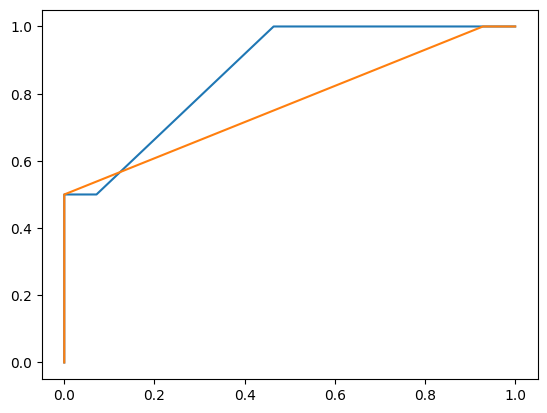

In [6]:
y1 = ada.predict_proba(X_test)[:,1]
y2 = gb.predict_proba(X_test)[:,1]
fpr1, tpr1, _ = roc_curve(y_test, y1)
fpr2, tpr2, _ = roc_curve(y_test, y2)
plt.plot(fpr1, tpr1)
plt.plot(fpr2, tpr2)
plt.show()

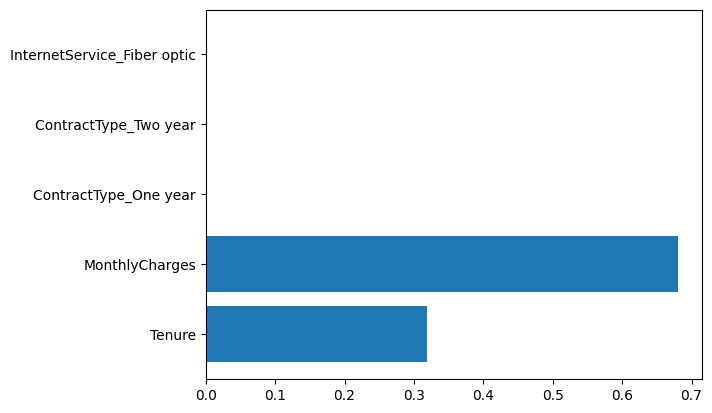

In [7]:
plt.barh(X.columns, gb.feature_importances_)
plt.show()